## MBENEFIT STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

mbenefit=pd.read_csv('../stock_data/mbenefit.csv') ## so it can be small letter. This is cool.
mbenefit=mbenefit.drop(columns=['high_price','low_price'])
mbenefit.rename(columns={'trade_date':'date'},inplace=True)
mbenefit['date']=pd.to_datetime(mbenefit['date'])
mbenefit['month']=mbenefit['date'].dt.month
mbenefit['quarter']=mbenefit['date'].dt.quarter
mbenefit['year']=mbenefit['date'].dt.year

mbenefit

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42817,MBENEFIT,2017-01-03,0.50,0.50,0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43377,MBENEFIT,2017-01-04,0.50,0.50,0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43487,MBENEFIT,2017-01-05,0.50,0.50,110000,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43597,MBENEFIT,2017-01-06,0.50,0.50,0,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43687,MBENEFIT,2017-01-09,0.50,0.50,100000,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298091,MBENEFIT,2026-07-13,3.53,3.53,3975989,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298529,MBENEFIT,2026-07-14,3.42,3.42,4947485,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298967,MBENEFIT,2026-07-15,3.64,3.64,3391823,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299405,MBENEFIT,2026-07-16,3.67,3.67,3299115,2026-07-16T15:10:03.113936+00:00,7,3,2026


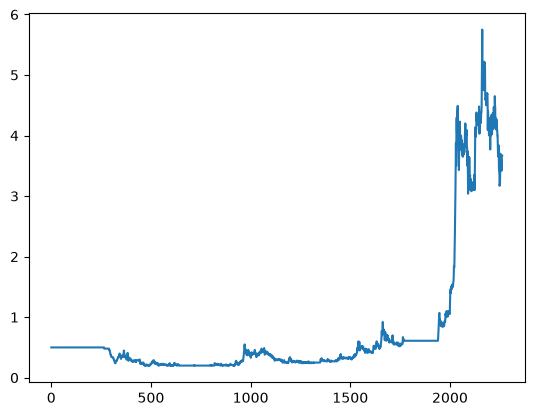

In [2]:
import matplotlib.pyplot as plt

plt.plot(mbenefit['close_price'])
plt.show()

In [3]:
mbenefit_end_month_df = (
    mbenefit
    .sort_values("date")
    .groupby(mbenefit["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

mbenefit_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45387,MBENEFIT,2017-01-31,0.50,0.50,0,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47209,MBENEFIT,2017-02-28,0.50,0.50,700000,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49325,MBENEFIT,2017-03-31,0.50,0.50,0,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51153,MBENEFIT,2017-04-28,0.50,0.50,0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53075,MBENEFIT,2017-05-31,0.50,0.50,500,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35328,MBENEFIT,2026-03-31,4.09,4.09,19627986,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281154,MBENEFIT,2026-04-30,4.03,4.03,9101779,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284220,MBENEFIT,2026-05-29,4.19,4.19,5816018,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294148,MBENEFIT,2026-06-30,3.17,3.17,8047558,2026-06-30T15:10:03.08168+00:00,6,2,2026


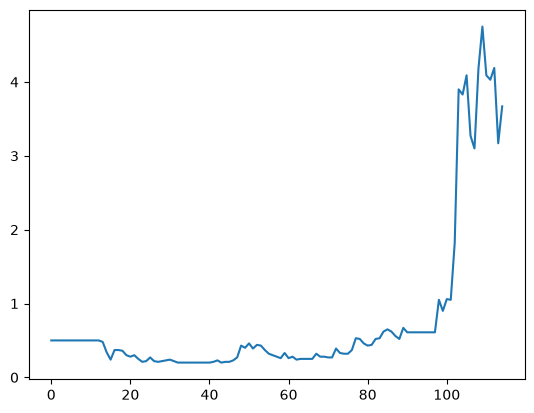

In [4]:
plt.plot(mbenefit_end_month_df['close_price'])
plt.show()

In [5]:
mbenefit_end_month_df['returns']=mbenefit_end_month_df['close_price'].pct_change()*100
mbenefit_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45387,MBENEFIT,2017-01-31,0.50,0.50,0,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47209,MBENEFIT,2017-02-28,0.50,0.50,700000,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49325,MBENEFIT,2017-03-31,0.50,0.50,0,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51153,MBENEFIT,2017-04-28,0.50,0.50,0,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53075,MBENEFIT,2017-05-31,0.50,0.50,500,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35328,MBENEFIT,2026-03-31,4.09,4.09,19627986,2026-03-31T15:00:02.085058+00:00,3,1,2026,-13.894737
111,281154,MBENEFIT,2026-04-30,4.03,4.03,9101779,2026-04-30T15:00:02.170664+00:00,4,2,2026,-1.466993
112,284220,MBENEFIT,2026-05-29,4.19,4.19,5816018,2026-05-29T15:00:02.455558+00:00,5,2,2026,3.970223
113,294148,MBENEFIT,2026-06-30,3.17,3.17,8047558,2026-06-30T15:10:03.08168+00:00,6,2,2026,-24.343675


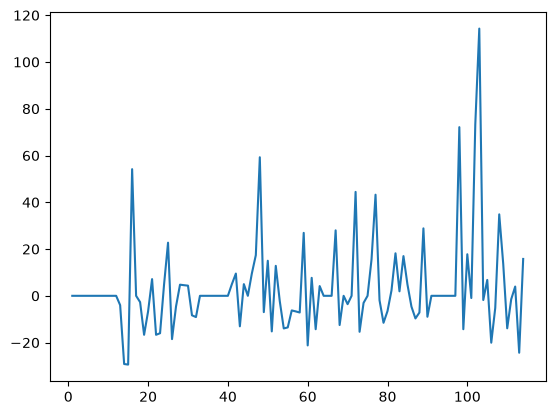

In [6]:
plt.plot(mbenefit_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(mbenefit_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-3.3630991901565124), np.float64(0.012283011487488216), 4, 109, {'1%': np.float64(-3.49181775886872), '5%': np.float64(-2.8884437992971588), '10%': np.float64(-2.5811201893779985)}, np.float64(895.8700384470226))
stationary


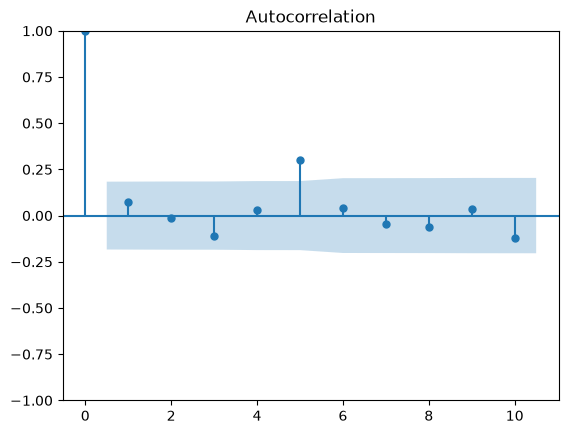

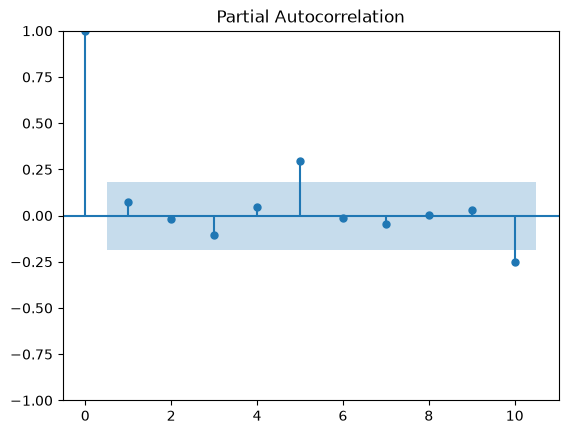

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(mbenefit_end_month_df['returns'].dropna(), lags=10)
plot_pacf(mbenefit_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=mbenefit_end_month_df['close_price'][:-10]
test=mbenefit_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -57.66844745383672]
[0, 0, 0, 0, 0, 1, -46.369224652469526]
[0, 0, 0, 0, 0, 2, -41.90833595631548]
[0, 0, 0, 0, 1, 0, -34.7281685328695]
[0, 0, 0, 0, 1, 1, -33.751193455060935]
[0, 0, 0, 0, 1, 2, -32.61317368147928]
[0, 0, 0, 0, 2, 0, -29.438803559465125]
[0, 0, 0, 0, 2, 1, -29.521029538994604]
[0, 0, 0, 0, 2, 2, -29.0207893609006]
[0, 0, 0, 1, 0, 0, -37.67950952910405]
[0, 0, 0, 1, 0, 1, -37.2630154418475]
[0, 0, 0, 1, 0, 2, -36.902250469638446]
[0, 0, 0, 1, 1, 0, -32.96675540344718]
[0, 0, 0, 1, 1, 1, -34.89731064923324]
[0, 0, 0, 1, 1, 2, -33.0948079005948]
[0, 0, 0, 1, 2, 0, -29.40064573267981]
[0, 0, 0, 1, 2, 1, -29.394538442892404]
[0, 0, 0, 1, 2, 2, -29.416577013553667]
[0, 0, 0, 2, 0, 0, -37.17579740216381]
[0, 0, 0, 2, 0, 1, -37.8831494006725]
[0, 0, 0, 2, 0, 2, -37.184526851363906]
[0, 0, 0, 2, 1, 0, -32.56007335911747]
[0, 0, 0, 2, 1, 1, -32.80735160087873]
[0, 0, 0, 2, 1, 2, -32.77655291617124]
[0, 0, 0, 2, 2, 0, -29.03504421591127]
[0, 0, 0, 2, 2, 1, -29

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
654,2,2,0,0,2,0,-148.350004
673,2,2,0,2,2,1,-140.056877
665,2,2,0,1,2,2,-139.487020
674,2,2,0,2,2,2,-139.445818
663,2,2,0,1,2,0,-139.247526
...,...,...,...,...,...,...,...
92,0,1,0,1,0,2,-0.003475
91,0,1,0,1,0,1,-0.002664
81,0,1,0,0,0,0,-0.002236
82,0,1,0,0,0,1,0.001474


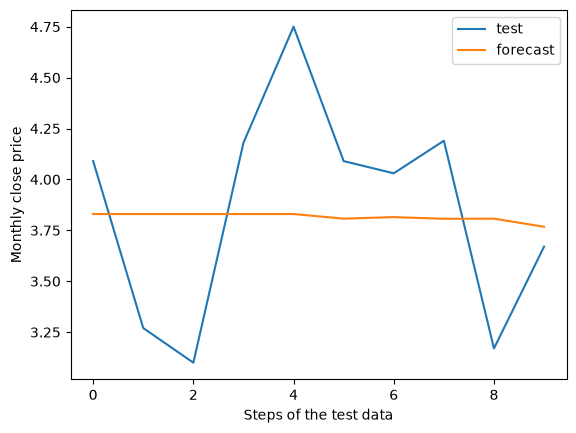

r2_score:  0.0015478202018452958
rmse:  0.5071147180249572
description:  count    115.000000
mean       0.770696
std        1.091082
min        0.200000
25%        0.250000
50%        0.390000
75%        0.585000
max        4.750000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=mbenefit_end_month_df['close_price'][:-10]
y_test=mbenefit_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,1,0), 
seasonal_order=(1,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', mbenefit_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=mbenefit_end_month_df['returns'].dropna()[:-10]
test=mbenefit_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.0034649973330025396]
[0, 0, 0, 0, 0, 1, -0.011624643424029246]
[0, 0, 0, 0, 0, 2, -0.03627828304337588]
[0, 0, 0, 0, 1, 0, -3.624903234771118]
[0, 0, 0, 0, 1, 1, -0.2961906533159626]
[0, 0, 0, 0, 1, 2, -0.47956430620305324]
[0, 0, 0, 0, 2, 0, -16.49073742566697]
[0, 0, 0, 0, 2, 1, -4.612940144756385]
[0, 0, 0, 0, 2, 2, -1.707170598013398]
[0, 0, 0, 1, 0, 0, -0.012592803950580267]
[0, 0, 0, 1, 0, 1, -0.01342804548784704]
[0, 0, 0, 1, 0, 2, -0.11863988984889762]
[0, 0, 0, 1, 1, 0, -0.9910374685011738]
[0, 0, 0, 1, 1, 1, -0.28625435872095384]
[0, 0, 0, 1, 1, 2, -0.5056421968980505]
[0, 0, 0, 1, 2, 0, -7.700734324213517]
[0, 0, 0, 1, 2, 1, -2.025630564644173]
[0, 0, 0, 1, 2, 2, -1.7026577858424101]
[0, 0, 0, 2, 0, 0, -0.02100579526918378]
[0, 0, 0, 2, 0, 1, -0.038692196150895475]
[0, 0, 0, 2, 0, 2, -0.24228387873333368]
[0, 0, 0, 2, 1, 0, -0.6123055396609076]
[0, 0, 0, 2, 1, 1, -0.4604046197638543]
[0, 0, 0, 2, 1, 2, -0.4988444050118912]
[0, 0, 0, 2, 2, 0, -3.79178539

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
215,0,2,1,2,2,2,-116707.212751
177,0,2,0,1,2,0,-2675.191462
174,0,2,0,1,1,0,-1814.366756
163,0,2,0,0,0,1,-1807.832987
171,0,2,0,1,0,0,-1805.527236
...,...,...,...,...,...,...,...
305,1,0,2,1,0,0,0.031085
306,1,0,2,1,0,1,0.031731
297,1,0,2,0,0,1,0.032126
314,1,0,2,2,0,0,0.039179


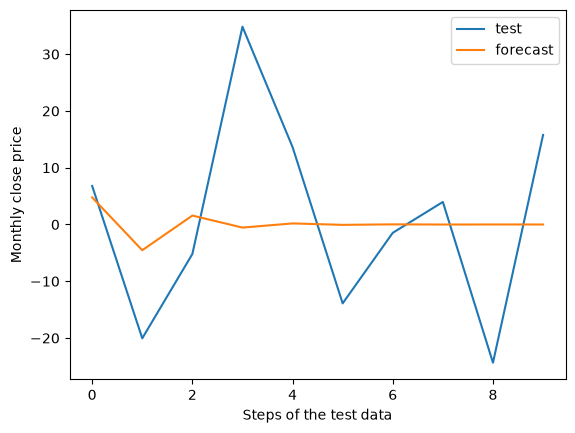

r2_score:  0.04892458843671632
rmse:  16.65626122989592
description:  count    114.000000
mean       3.356080
std       20.298971
min      -29.411765
25%       -6.453804
50%        0.000000
75%        4.819508
max      114.285714
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=mbenefit_end_month_df['returns'].dropna()[:-10]
y_test=mbenefit_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,0,2), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', mbenefit_end_month_df.returns.dropna().describe())